In [1]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [50]:
df = pd.read_csv(
    "/content/sentiment-analysis.csv",
    engine='python',
    on_bad_lines='skip')

print(df.head())
print(df.info())
print(df.shape)
print(df.columns)

  Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score
0  "I love this product!", Positive, Twitter, 202...                     
1  "The service was terrible.", Negative, Yelp Re...                     
2  "This movie is amazing!", Positive, IMDb, 2023...                     
3  "I'm so disappointed with their customer suppo...                     
4  "Just had the best meal of my life!", Positive...                     
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 1 columns):
 #   Column                                                                   Non-Null Count  Dtype 
---  ------                                                                   --------------  ----- 
 0   Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score  96 non-null     object
dtypes: object(1)
memory usage: 900.0+ bytes
None
(96, 1)
Index(['Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score'], dtype='obj

In [51]:
import pandas as pd

# Read raw file
df = pd.read_csv(
    "/content/sentiment-analysis.csv",
    header=None)

# splitting the column

df = df[0].str.split(",", expand = True)
df.columns = ['Text', 'Sentiment', 'Source', 'Date/Time', 'User ID', 'Location', 'Confidence Score']

# remove first row

df = df.iloc[1:]
df.reset_index(drop=True, inplace=True)

# View dataset
print(df.head())

print(df.info())

                                                Text  Sentiment  \
0                             "I love this product!"   Positive   
1                        "The service was terrible."   Negative   
2                           "This movie is amazing!"   Positive   
3  "I'm so disappointed with their customer suppo...   Negative   
4               "Just had the best meal of my life!"   Positive   

          Source             Date/Time       User ID      Location  \
0        Twitter   2023-06-15 09:23:14      @user123      New York   
1   Yelp Reviews   2023-06-15 11:45:32       user456   Los Angeles   
2           IMDb   2023-06-15 14:10:22   moviefan789        London   
3   Online Forum   2023-06-15 17:35:11    forumuser1       Toronto   
4    TripAdvisor   2023-06-16 08:50:59      foodie22         Paris   

  Confidence Score  
0             0.85  
1             0.65  
2             0.92  
3             0.78  
4             0.88  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [52]:
df.drop(['Source', 'Date/Time', 'User ID', 'Location'], axis = 1, inplace = True)
print(df)

                                                 Text  Sentiment  \
0                              "I love this product!"   Positive   
1                         "The service was terrible."   Negative   
2                            "This movie is amazing!"   Positive   
3   "I'm so disappointed with their customer suppo...   Negative   
4                "Just had the best meal of my life!"   Positive   
..                                                ...        ...   
93  "I can't stop listening to this song. It's my ...   Positive   
94  "Their website is so confusing and poorly desi...   Negative   
95  "I had an incredible experience at the theme p...   Positive   
96                                                NaN        NaN   
97                                                NaN        NaN   

   Confidence Score  
0              0.85  
1              0.65  
2              0.92  
3              0.78  
4              0.88  
..              ...  
93             0.91  
94     

In [53]:
df.columns

Index(['Text', 'Sentiment', 'Confidence Score'], dtype='object')

In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

le = LabelEncoder()

df['Confidence Score'] = pd.to_numeric(df['Confidence Score'], errors='coerce')

imputer_categorical = SimpleImputer(strategy='most_frequent')
imputer_numerical = SimpleImputer(strategy='mean')

for col in df.columns:
  if df[col].dtype == "object":
    df[col] = imputer_categorical.fit_transform(df[[col]])[:, 0]
    df[col] = le.fit_transform(df[col])
  elif df[col].dtype in ['int64', 'float64']:
    df[col] = imputer_numerical.fit_transform(df[[col]])[:, 0]

scaler = StandardScaler()
df['Confidence Score'] = scaler.fit_transform(df[['Confidence Score']])

In [56]:
y = df['Sentiment'].astype(int)

print(df)
# Define X by dropping the target variable.
X = df.drop('Sentiment', axis = 1)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

    Text  Sentiment  Confidence Score
0     10          1      4.440988e-01
1     54          0     -1.081249e+00
2     68          1      9.779706e-01
3     21          0     -8.977310e-02
4     22          1      6.729010e-01
..   ...        ...               ...
93     2          1      9.017032e-01
94    60          0     -8.524472e-01
95     9          1      7.491684e-01
96     1          1      8.467383e-16
97     1          1      8.467383e-16

[98 rows x 3 columns]
Shape of x_train: (78, 2)
Shape of y_train: (78,)
Shape of x_test: (20, 2)
Shape of y_test: (20,)


In [57]:
print(y_train.head())

39    0
97    1
21    1
12    1
36    1
Name: Sentiment, dtype: int64


In [59]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

xgb_model = XGBRegressor(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    colsample_bytree=0.7,
    subsample=0.8,
    objective='reg:squarederror' # Objective for regression
)

xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred.round())
precision = precision_score(y_test, y_pred.round(), average='weighted')
recall = recall_score(y_test, y_pred.round(), average='weighted')
f1 = f1_score(y_test, y_pred.round(), average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")



Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

[[ 9  0]
 [ 0 11]]


Text(95.72222222222221, 0.5, 'Truth')

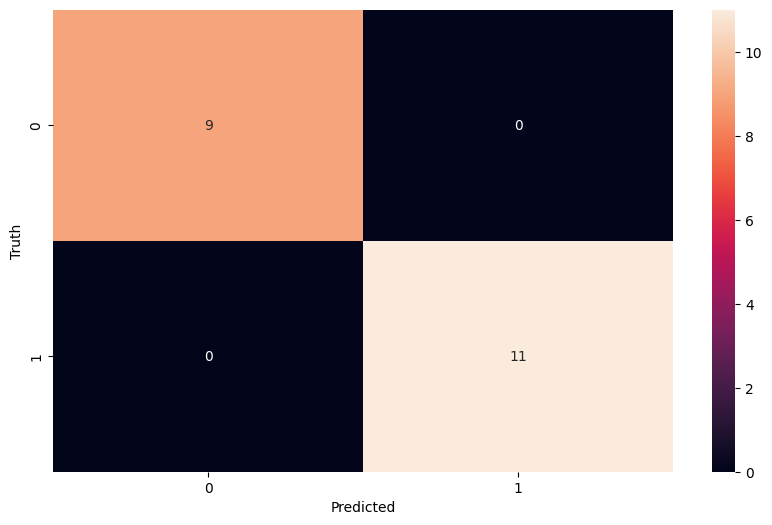

In [63]:
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred.round()))
print(confusion_matrix(y_test, y_pred.round()))

plt.figure(figsize = (10,6))
sns.heatmap(confusion_matrix(y_test, y_pred.round()), annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [66]:
import joblib
if joblib.dump(xgb_model, 'sentiment_analysis.pkl'):
  print("model saved")

model saved
